In [7]:
import pandas as pd
df = pd.read_csv('c:/data/boston/house.csv')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,target,target2
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,1
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,0
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,1
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,1
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,1


In [8]:
X = df.iloc[:, :-2]
y = df.iloc[:, [-2]]

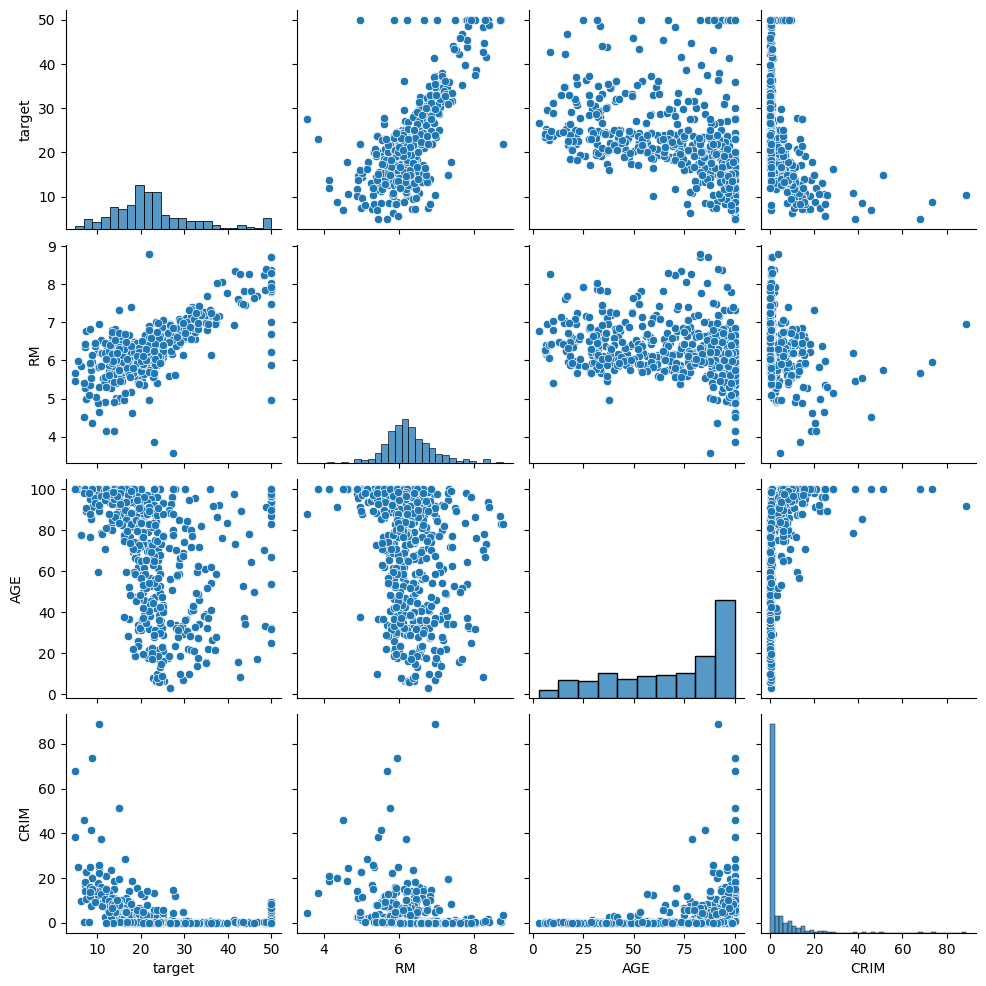

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(df[['target','RM','AGE','CRIM']])
plt.show()

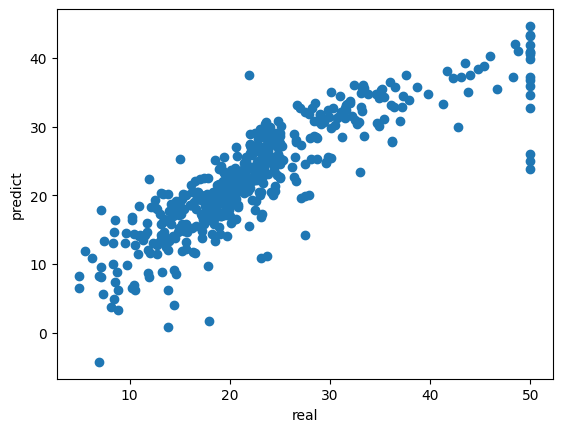

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression().fit(X,y)
predicted = model.predict(X)

plt.scatter(y, predicted)
plt.xlabel('real')
plt.ylabel('predict')
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=10)
model = LinearRegression().fit(X_train, y_train)
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

0.7495400632086622
0.699625577298312


In [12]:
coef = model.coef_
intercept = model.intercept_
print(coef)
print(intercept)

[[-1.53776087e-01  6.50159270e-02 -2.42597326e-02  1.62203309e+00
  -1.52999306e+01  3.35196668e+00  1.13259963e-02 -1.54810871e+00
   3.02641886e-01 -1.22317535e-02 -8.11539044e-01  1.29504798e-02
  -5.44861583e-01]]
[34.24483703]


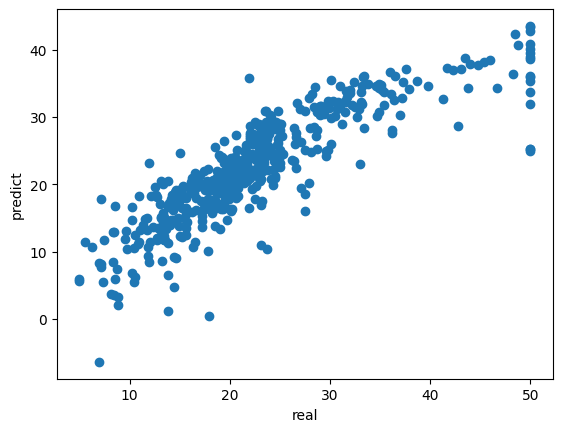

In [13]:
pred = model.predict(X)
plt.scatter(y,pred)
plt.xlabel('real')
plt.ylabel('predict')
plt.show()

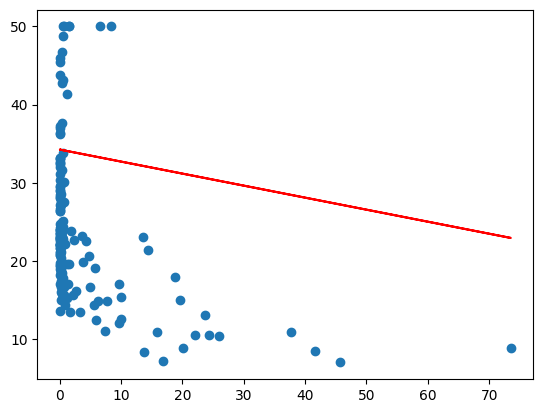

In [14]:
plt.scatter(X_test['CRIM'], y_test)
plt.plot(X_test['CRIM'], coef[0][0]*X_test['CRIM'] + intercept, c='r')
plt.show()

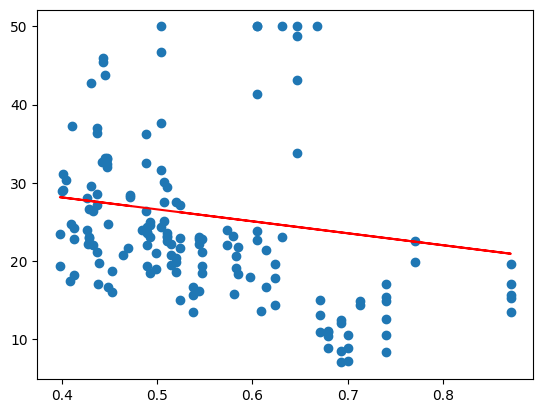

In [15]:
plt.scatter(X_test['NOX'], y_test)
plt.plot(X_test['NOX'], coef[0][4]*X_test['NOX'] + intercept, c='r')
plt.show()

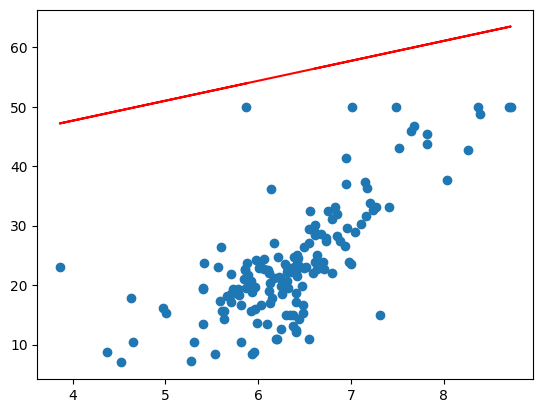

In [16]:
plt.scatter(X_test['RM'], y_test)
plt.plot(X_test['RM'], coef[0][5]*X_test['RM'] + intercept, c='r')
plt.show()

In [17]:
import statsmodels.api as sm
model_boston2 = sm.OLS(y,X)
result_boston2 = model_boston2.fit()
result_boston2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 target   R-squared (uncentered):                   0.959
Model:                            OLS   Adj. R-squared (uncentered):              0.958
Method:                 Least Squares   F-statistic:                              891.3
Date:                Thu, 15 Jan 2026   Prob (F-statistic):                        0.00
Time:                        12:41:57   Log-Likelihood:                         -1523.8
No. Observations:                 506   AIC:                                      3074.
Df Residuals:                     493   BIC:                                      3128.
Df Model:                          13                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
CRIM          -0.0929      0.034     -2.699      0.007      -0.161      -0.025
ZN             0.0487      0.014      3.382      0.001       0.020       0.077
INDUS         -0.0041      0.064     -0.063      0.950      -0.131       0.123
CHAS           2.8540      0.904      3.157      0.002       1.078       4.630
NOX           -2.8684      3.359     -0.854      0.394      -9.468       3.731
RM             5.9281      0.309     19.178      0.000       5.321       6.535
AGE           -0.0073      0.014     -0.526      0.599      -0.034       0.020
DIS           -0.9685      0.196     -4.951      0.000      -1.353      -0.584
RAD            0.1712      0.067      2.564      0.011       0.040       0.302
TAX           -0.0094      0.004     -2.395      0.017      -0.017      -0.002
PTRATIO       -0.3922      0.110     -3.570      0.000      -0.608      -0.176
B              0.0149      0.003      5.528      0.000       0.010       0.020
LSTAT         -0.4163      0.051     -8.197      0.000      -0.516      -0.317
==============================================================================
Omnibus:                      204.082   Durbin-Watson:                   0.999
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1374.225
Skew:                           1.609   Prob(JB):                    3.90e-299
Kurtosis:                      10.404   Cond. No.                     8.50e+03
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 8.5e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [18]:
X.corr()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993


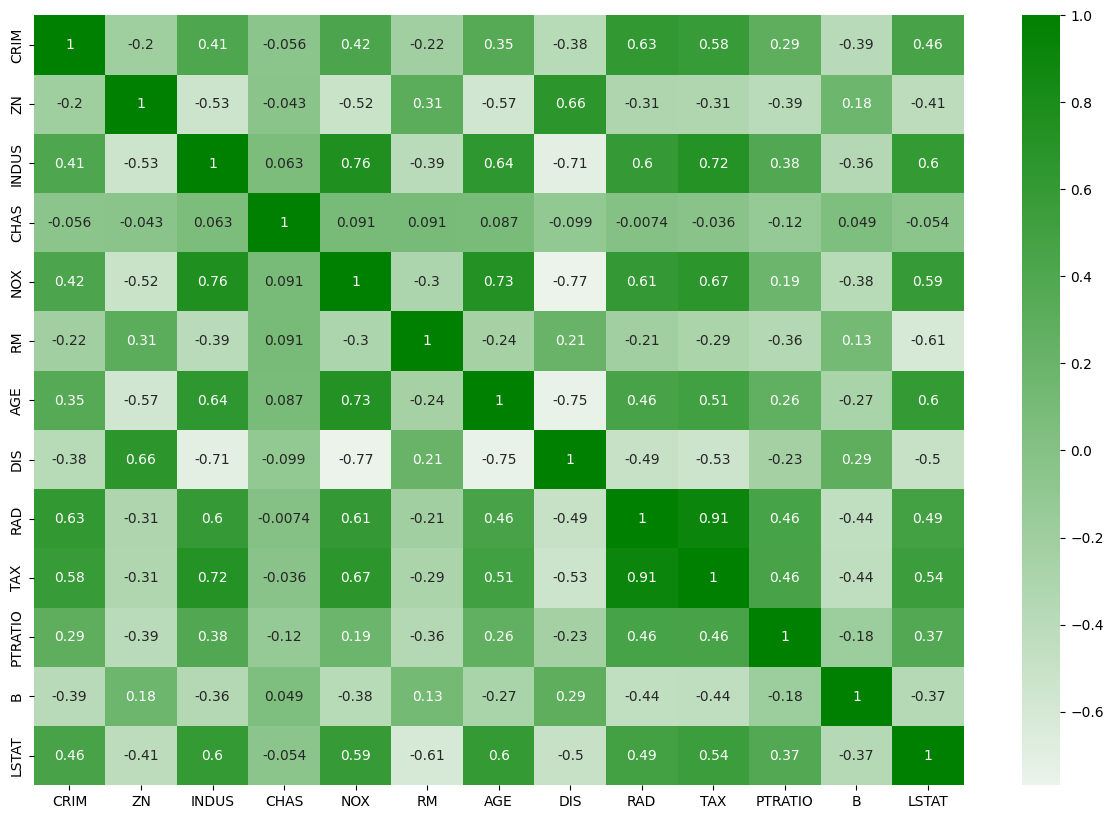

In [19]:
plt.figure(figsize=(15,10))
cmap=sns.light_palette('green',as_cmap=True)
sns.heatmap(X.corr(), annot=True, cmap=cmap)
plt.show()

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif=pd.DataFrame()
vif['VIF']=[variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['변수']=X.columns
vif=vif.sort_values('VIF').reset_index(drop=True)
vif

,VIF,변수
0,1.152952,CHAS
1,2.100373,CRIM
2,2.844013,ZN
3,11.102025,LSTAT
4,14.485758,INDUS
5,14.699652,DIS
6,15.167725,RAD
7,20.104943,B
8,21.386850,AGE
9,61.227274,TAX


In [21]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'target', 'target2'],
      dtype='object')

In [22]:
##후진제거법으로 p-value가 0.05보다 큰 변수들 하나씩 탈락

In [23]:
#INDUS 제거
arr=df[['CRIM', 'ZN', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT']]
dfX = pd.DataFrame(arr, columns=['CRIM', 'ZN', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT'])
model_boston3 = sm.OLS(y, dfX)
result_boston3 = model_boston3.fit()
result_boston3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 target   R-squared (uncentered):                   0.959
Model:                            OLS   Adj. R-squared (uncentered):              0.958
Method:                 Least Squares   F-statistic:                              967.5
Date:                Thu, 15 Jan 2026   Prob (F-statistic):                        0.00
Time:                        12:41:58   Log-Likelihood:                         -1523.8
No. Observations:                 506   AIC:                                      3072.
Df Residuals:                     494   BIC:                                      3122.
Df Model:                          12                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
CRIM          -0.0928      0.034     -2.701      0.007      -0.160      -0.025
ZN             0.0488      0.014      3.412      0.001       0.021       0.077
CHAS           2.8482      0.898      3.171      0.002       1.083       4.613
NOX           -2.9275      3.222     -0.909      0.364      -9.258       3.403
RM             5.9318      0.303     19.555      0.000       5.336       6.528
AGE           -0.0073      0.014     -0.527      0.598      -0.034       0.020
DIS           -0.9655      0.189     -5.099      0.000      -1.337      -0.593
RAD            0.1723      0.064      2.687      0.007       0.046       0.298
TAX           -0.0095      0.004     -2.693      0.007      -0.016      -0.003
PTRATIO       -0.3930      0.109     -3.607      0.000      -0.607      -0.179
B              0.0149      0.003      5.544      0.000       0.010       0.020
LSTAT         -0.4165      0.051     -8.225      0.000      -0.516      -0.317
==============================================================================
Omnibus:                      204.123   Durbin-Watson:                   0.999
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1374.966
Skew:                           1.609   Prob(JB):                    2.69e-299
Kurtosis:                      10.406   Cond. No.                     8.16e+03
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 8.16e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [24]:
#INDUS, AGE 제거
arr=df[['CRIM', 'ZN', 'CHAS', 'NOX', 'RM', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT']]
dfX = pd.DataFrame(arr, columns=['CRIM', 'ZN', 'CHAS', 'NOX', 'RM', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT'])
model_boston3 = sm.OLS(y, dfX)
result_boston3 = model_boston3.fit()
result_boston3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 target   R-squared (uncentered):                   0.959
Model:                            OLS   Adj. R-squared (uncentered):              0.958
Method:                 Least Squares   F-statistic:                              1057.
Date:                Thu, 15 Jan 2026   Prob (F-statistic):                        0.00
Time:                        12:41:58   Log-Likelihood:                         -1523.9
No. Observations:                 506   AIC:                                      3070.
Df Residuals:                     495   BIC:                                      3116.
Df Model:                          11                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
CRIM          -0.0928      0.034     -2.702      0.007      -0.160      -0.025
ZN             0.0498      0.014      3.508      0.000       0.022       0.078
CHAS           2.8248      0.897      3.151      0.002       1.063       4.586
NOX           -3.3945      3.096     -1.097      0.273      -9.477       2.688
RM             5.8979      0.296     19.909      0.000       5.316       6.480
DIS           -0.9298      0.177     -5.262      0.000      -1.277      -0.583
RAD            0.1743      0.064      2.724      0.007       0.049       0.300
TAX           -0.0096      0.004     -2.710      0.007      -0.016      -0.003
PTRATIO       -0.3951      0.109     -3.631      0.000      -0.609      -0.181
B              0.0149      0.003      5.531      0.000       0.010       0.020
LSTAT         -0.4254      0.048     -8.917      0.000      -0.519      -0.332
==============================================================================
Omnibus:                      200.446   Durbin-Watson:                   1.005
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1313.904
Skew:                           1.584   Prob(JB):                    4.89e-286
Kurtosis:                      10.230   Cond. No.                     7.79e+03
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 7.79e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [25]:
#INDUS, AGE, NOX 제거
arr=df[['CRIM', 'ZN', 'CHAS', 'RM', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT']]
dfX = pd.DataFrame(arr, columns=['CRIM', 'ZN', 'CHAS', 'RM', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT'])
model_boston3 = sm.OLS(y, dfX)
result_boston3 = model_boston3.fit()
result_boston3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 target   R-squared (uncentered):                   0.959
Model:                            OLS   Adj. R-squared (uncentered):              0.958
Method:                 Least Squares   F-statistic:                              1162.
Date:                Thu, 15 Jan 2026   Prob (F-statistic):                        0.00
Time:                        12:41:58   Log-Likelihood:                         -1524.5
No. Observations:                 506   AIC:                                      3069.
Df Residuals:                     496   BIC:                                      3111.
Df Model:                          10                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
CRIM          -0.0911      0.034     -2.655      0.008      -0.158      -0.024
ZN             0.0513      0.014      3.634      0.000       0.024       0.079
CHAS           2.7185      0.891      3.049      0.002       0.967       4.470
RM             5.7145      0.245     23.368      0.000       5.234       6.195
DIS           -0.8666      0.167     -5.187      0.000      -1.195      -0.538
RAD            0.1828      0.064      2.878      0.004       0.058       0.308
TAX           -0.0109      0.003     -3.296      0.001      -0.017      -0.004
PTRATIO       -0.4002      0.109     -3.681      0.000      -0.614      -0.187
B              0.0145      0.003      5.442      0.000       0.009       0.020
LSTAT         -0.4492      0.042    -10.575      0.000      -0.533      -0.366
==============================================================================
Omnibus:                      198.045   Durbin-Watson:                   0.999
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1250.213
Skew:                           1.575   Prob(JB):                    3.31e-272
Kurtosis:                      10.027   Cond. No.                     2.24e+03
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 2.24e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [26]:
#INDUS, AGE, NOX, PTRATIO 제거
arr=df[['CRIM', 'ZN', 'CHAS', 'RM', 'DIS', 'RAD', 'TAX',
       'B', 'LSTAT']]
dfX = pd.DataFrame(arr, columns=['CRIM', 'ZN', 'CHAS', 'RM', 'DIS', 'RAD', 'TAX',
       'B', 'LSTAT'])
model_boston3 = sm.OLS(y, dfX)
result_boston3 = model_boston3.fit()
result_boston3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 target   R-squared (uncentered):                   0.958
Model:                            OLS   Adj. R-squared (uncentered):              0.957
Method:                 Least Squares   F-statistic:                              1258.
Date:                Thu, 15 Jan 2026   Prob (F-statistic):                        0.00
Time:                        12:41:58   Log-Likelihood:                         -1531.4
No. Observations:                 506   AIC:                                      3081.
Df Residuals:                     497   BIC:                                      3119.
Df Model:                           9                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
CRIM          -0.0930      0.035     -2.678      0.008      -0.161      -0.025
ZN             0.0723      0.013      5.528      0.000       0.047       0.098
CHAS           2.9803      0.900      3.312      0.001       1.212       4.748
RM             5.1644      0.196     26.348      0.000       4.779       5.550
DIS           -1.1247      0.154     -7.325      0.000      -1.426      -0.823
RAD            0.1868      0.064      2.905      0.004       0.060       0.313
TAX           -0.0144      0.003     -4.512      0.000      -0.021      -0.008
B              0.0118      0.003      4.546      0.000       0.007       0.017
LSTAT         -0.5118      0.039    -12.984      0.000      -0.589      -0.434
==============================================================================
Omnibus:                      172.152   Durbin-Watson:                   0.971
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              820.584
Skew:                           1.433   Prob(JB):                    6.49e-179
Kurtosis:                       8.541   Cond. No.                     2.23e+03
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 2.23e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [27]:
##결론
# 수정.R제곱 : 0.0958->0.0957
# 개별변수의 p value : 유의하지않은 변수 3개 제거로 모든 값이 유의함
# VIF가 가장높은 PTRATIO 제거했으니 의미있는지 모르겠음